# ⚡ Training Workflow (1–14)
이 구간은 빠르게 데이터 일부로 end-to-end 학습과 검증을 수행하는 스모크 테스트 플로우입니다. 아래 순서대로 각 셀을 실행하세요.

# 1. Import required libraries


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'
import sys, math, json, random, contextlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torch_geometric.datasets import AirfRANS
from torch_geometric.data import Data, Batch
from matplotlib.tri import Triangulation
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch_geometric.data import Data
from src.navier_stokes_physics_loss import NavierStokesPhysicsLoss
from src.airfrans_utils import prepare_airfrans_graph_for_physics, estimate_node_area, build_bc_masks_airfrans
import contextlib
import wandb  
from torch.cuda.amp import GradScaler, autocast

def get_lr(optim):
    return optim.param_groups[0].get('lr', None)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(42)
print('SmokeTest | PyTorch:', torch.__version__, '| CUDA?', torch.cuda.is_available())

/home/chun/work/airfrans_gnn/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SmokeTest | PyTorch: 2.10.0+cu128 | CUDA? True


# 2. Set Configuration

In [2]:
# 2) Configuration (minimal for smoke)
from dataclasses import dataclass, asdict

@dataclass
class SmokeCfg:
    seed: int = 42
    task: str = 'full'
    root: str = 'Dataset'
    # subsample graph count for smoke
    limit_train: int = 800
    limit_val: int = 200

    # training
    batch_size: int = 1
    epochs: int = 100
    hidden: int = 32
    layers: int = 12
    lr: float = 4e-4
    weight_decay: float = 1e-2  # typical AdamW wd
    betas: tuple[float, float] = (0.9, 0.95)
    eps: float = 1e-8
    amp: bool = False

    # lr scheduler: 'cosine', 'cosine_warm_restarts', 'reduce_on_plateau', or None
    lr_scheduler: str = 'cosine'
    # cosine params
    cosine_T_max: int = 80  # epochs
    cosine_eta_min: float = 1e-6
    # warm restarts params
    wr_T_0: int = 10
    wr_T_mult: int = 1
    wr_eta_min: float = 1e-6
    # reduce on plateau params
    rop_factor: float = 0.5
    rop_patience: int = 5
    rop_min_lr: float = 1e-6

    # Physics-Informed Loss Configuration
    # =====================================
    # Curriculum learning schedule
    ramp_start_epoch: int = 40              # Epoch to start ramping physics losses
    ramp_epochs: int = 60                   # Number of epochs to ramp up
    ramp_mode: str = 'linear'               # 'linear' or 'cosine'
    
    # MSE/Data loss
    data_loss_weight: float = 1.0           # Weight for MSE loss (constant)
    
    # Continuity equation loss
    continuity_loss_weight: float = 0.05    # Initial continuity weight
    continuity_target_weight: float = 0.20  # Target continuity weight after ramp
    
    # Momentum equation loss  
    momentum_loss_weight: float = 0.05      # Initial momentum weight
    momentum_target_weight: float = 0.20    # Target momentum weight after ramp
    
    # Boundary condition loss
    bc_loss_weight: float = 0.1              # Weight for boundary condition loss
    
    # Physics parameters
    chord_length: float = 1.0               # Airfoil chord length
    nu_molecular: float = 1.5e-5            # Molecular viscosity
    dynamic_uref_from_data: bool = True     # Compute reference velocity from data
    dynamic_re_from_data: bool = True       # Compute Reynolds number from data
    uinf_from: str = 'inlet'                # 'inlet', 'farfield', or 'robust'
    
    # Stability & outlier control
    use_huber_for_physics: bool = True       # Use Huber loss for physics terms
    huber_delta: float = 0.05                 # Huber loss delta parameter
    use_perimeter_norm_for_div: bool = True   # Normalize divergence by perimeter
    div_area_floor_factor: float = 0.25       # Area floor factor for stability
    div_min_degree: int = 2                     # Minimum node degree for physics loss

    # Debug & monitoring
    physics_debug: bool = False              # Enable physics loss debugging
    physics_debug_level: int = 1              # Debug verbosity (1=summary, 2=detailed)
    physics_debug_every: int = 50           # Log debug info every N steps

    # Global Context & Attention Configuration
    use_global_tokens: bool = True           # Enable/disable global tokens
    num_global_tokens: int = 2               # Number of global tokens
    attention_heads: int = 2                 # Multi-head attention heads
    attention_layers: int = 2               # Number of transformer layers
    attention_dropout: float = 0.0           # Attention dropout rate
    use_cross_attention: bool = True         # Cross-attention between local and global
    global_pooling_type: str = 'attention'   # 'mean', 'max', 'attention', 'set2set'
    positional_encoding: bool = False         # Use positional encoding
    pos_encoding_max_len: int = 50000        # Max sequence length for positional encoding
    # Advanced attention options
    use_residual_attention: bool = True      # Residual connections in attention
    attention_normalization: str = 'layer'   # 'layer', 'batch', 'rms'
    temperature_scaling: bool = False        # Temperature scaling for attention
    attention_bias: bool = False             # Use bias in attention projections

    # W&B Artifact 관리
    use_wandb_artifacts: bool = False        # W&B artifact 사용 여부
    artifact_save_best_only: bool = True     # best 모델만 업로드
    artifact_save_interval: int = 50         # periodic 저장 간격 (epochs)
    
    # Checkpoint 관리
    ckpt_dir: str = "checkpoints"           # 로컬 체크포인트 디렉토리
    ckpt_interval: int = 5                  # 로컬 체크포인트 저장 간격
    
    # W&B 설정
    wandb_project: str = "airfrans-gnn"
    wandb_mode: str = "online"              # "online", "offline", "disabled"
    log_every_n_steps: int = -1             # 로깅 빈도
    log_epoch_only: bool = True             # Epoch 로깅만 사용

scfg = SmokeCfg()
set_seed(scfg.seed)
print('Smoke config:', asdict(scfg))

Smoke config: {'seed': 42, 'task': 'full', 'root': 'Dataset', 'limit_train': 800, 'limit_val': 200, 'batch_size': 1, 'epochs': 100, 'hidden': 32, 'layers': 12, 'lr': 0.0004, 'weight_decay': 0.01, 'betas': (0.9, 0.95), 'eps': 1e-08, 'amp': False, 'lr_scheduler': 'cosine', 'cosine_T_max': 80, 'cosine_eta_min': 1e-06, 'wr_T_0': 10, 'wr_T_mult': 1, 'wr_eta_min': 1e-06, 'rop_factor': 0.5, 'rop_patience': 5, 'rop_min_lr': 1e-06, 'ramp_start_epoch': 40, 'ramp_epochs': 60, 'ramp_mode': 'linear', 'data_loss_weight': 1.0, 'continuity_loss_weight': 0.05, 'continuity_target_weight': 0.2, 'momentum_loss_weight': 0.05, 'momentum_target_weight': 0.2, 'bc_loss_weight': 0.1, 'chord_length': 1.0, 'nu_molecular': 1.5e-05, 'dynamic_uref_from_data': True, 'dynamic_re_from_data': True, 'uinf_from': 'inlet', 'use_huber_for_physics': True, 'huber_delta': 0.05, 'use_perimeter_norm_for_div': True, 'div_area_floor_factor': 0.25, 'div_min_degree': 2, 'physics_debug': False, 'physics_debug_level': 1, 'physics_debu

# 3. Load dataset indices

In [3]:
from torch_geometric.transforms import BaseTransform

class _PreparePhysics(BaseTransform):
    def forward(self, data):
        # edge_attr_dxdy가 이미 있을 경우 build_edge_attr_dxdy는 생략되고 나머지만 수행
        return prepare_airfrans_graph_for_physics(data, verbose=False)

# 3) Load dataset indices (train/val split)
assert os.path.isdir(scfg.root), f"Dataset folder not found: {scfg.root}"
try:
    ds_train = AirfRANS(root=scfg.root, train=True, task=scfg.task, transform=_PreparePhysics())
    ds_test  = AirfRANS(root=scfg.root, train=False, task=scfg.task, transform=_PreparePhysics())
except TypeError:
    ds_train = AirfRANS(root=scfg.root, train=True, task=scfg.task, transform=_PreparePhysics())
    ds_test  = AirfRANS(root=scfg.root, train=False, task=scfg.task, transform=_PreparePhysics())

if scfg.task == 'scarce':
    # Scarce provides train only; create 90/10 split from ds_train
    n = len(ds_train)
    ids_all = list(range(n))
    random.Random(scfg.seed).shuffle(ids_all)
    
    # Split into train and val
    n_train = scfg.limit_train if scfg.limit_train > 0 else int(0.9 * n)
    n_val = scfg.limit_val if scfg.limit_val > 0 else (n - n_train)
    
    ids_train = ids_all[:n_train]
    ids_val = ids_all[n_train:n_train + n_val]
    
    train_raw = Subset(ds_train, ids_train)
    val_raw = Subset(ds_train, ids_val)
    
else:
    ids_train = list(range(min(scfg.limit_train+scfg.limit_val, len(ds_train))))
    ids_val = ids_train[-scfg.limit_val:] if scfg.limit_val>0 else []
    ids_train = ids_train[:scfg.limit_train] if scfg.limit_train>0 else ids_train
    train_raw = Subset(ds_train, ids_train)
    val_raw   = Subset(ds_train, ids_val) if ids_val else []

print('Loaded subset indices:', len(train_raw), 'train |', len(val_raw) if isinstance(val_raw, Subset) else 0, 'val/test')

Loaded subset indices: 800 train | 200 val/test


# 4. Load prebuilt graphs and ensure features (index-aligned with raw)

In [4]:
# 6) Load prebuilt graphs and ensure features (index-aligned with raw)
import glob, os, re
from src.utils import with_pos2, prep_graph, validate_edges, _prep_graph_for_norm

USE_PREBUILT = True
if scfg.task == 'full':
    PREBUILT_ROOT = 'prebuilt_edges/full'
else:
    PREBUILT_ROOT = 'prebuilt_edges/scarce'
    
PREBUILT_TRAIN_DIR = f"{PREBUILT_ROOT}/train"
PREBUILT_TEST_DIR  = f"{PREBUILT_ROOT}/test"
DOWNSAMPLED_ROOT = f"downsampled_graphs/{scfg.task}"

# Load prebuilt edge graphs
train_edge_files = sorted(glob.glob(os.path.join(PREBUILT_TRAIN_DIR, 'graph_*.pt')))
val_edge_files   = sorted(glob.glob(os.path.join(PREBUILT_TEST_DIR,  'graph_*.pt')))
print(f"[prebuilt] found: {len(train_edge_files)} train and {len(val_edge_files)} val graphs under {PREBUILT_ROOT}")

# Load tensors and prepare
train_edges = []
for p in train_edge_files:
    d = torch.load(p, map_location='cpu', weights_only=False)
    if not isinstance(d, Data):
        d = Data(**d)
    train_edges.append(prep_graph(d))

val_edges = []
for p in val_edge_files:
    d = torch.load(p, map_location='cpu', weights_only=False)
    if not isinstance(d, Data):
        d = Data(**d)
    val_edges.append(prep_graph(d))

print(f"Graphs prepared. Example dims -> x: {train_edges[0].x.shape if len(train_edges)>0 else None}  edge_attr: {train_edges[0].edge_attr.shape if (len(train_edges)>0 and hasattr(train_edges[0],'edge_attr') and train_edges[0].edge_attr is not None) else None}")

validate_edges(train_edges, 'train_edges')

[prebuilt] found: 800 train and 200 val graphs under prebuilt_edges/full
Graphs prepared. Example dims -> x: torch.Size([17987, 5])  edge_attr: torch.Size([68640, 5])
[validate] train_edges: total=800 bad=0


# 5. Nnormalized datasets


In [5]:
if scfg.task == 'scarce':
    n = len(train_edges)
    n_train = int(n * 0.9)
    ids_all = list(range(n))
    random.Random(scfg.seed).shuffle(ids_all)
    ids_train = ids_all[:n_train]
    ids_val = ids_all[n_train:]

    # Use prebuilt graphs, not raw dataset
    train_edges_subset = [train_edges[i] for i in ids_train]
    val_edges_subset = [train_edges[i] for i in ids_val] if ids_val else []
else:
    train_edges_subset = train_edges[:scfg.limit_train] if scfg.limit_train > 0 else train_edges
    val_edges_subset = val_edges[:scfg.limit_val] if scfg.limit_val > 0 else val_edges

train_prepped = [_prep_graph_for_norm(g) for g in train_edges_subset]
val_prepped   = [_prep_graph_for_norm(g) for g in val_edges_subset] if isinstance(val_edges_subset, list) else []

# 8b) Fit scalers on train_prepped
if 'StandardScaler' not in globals():
    class StandardScaler:
        def __init__(self):
            self.mean = None
            self.std = None
        def fit(self, t: torch.Tensor):
            self.mean = t.mean(dim=0)
            self.std = t.std(dim=0).clamp_min(1e-8)
            return self
        def transform(self, t: torch.Tensor):
            return (t - self.mean) / self.std
        def inverse(self, t: torch.Tensor):
            return t * self.std + self.mean

# Concatenate node features/targets across train graphs for fitting
X_train = torch.cat([d.x for d in train_prepped if hasattr(d, 'x') and d.x is not None], dim=0)
Y_train = torch.cat([d.y for d in train_prepped if hasattr(d, 'y') and d.y is not None], dim=0)

x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(Y_train)

# 8c) Build normalized dataset wrappers
class NormalizedDataset(torch.utils.data.Dataset):
    def __init__(self, graphs, x_scaler, y_scaler):
        self.graphs = graphs
        self.x_scaler = x_scaler
        self.y_scaler = y_scaler
        
    def __len__(self):
        return len(self.graphs)
        
    def __getitem__(self, idx: int):
        d = self.graphs[idx]
        dm = Data(**{k: v for k, v in d})
        dm.x = self.x_scaler.transform(d.x)
        if hasattr(d, 'y') and d.y is not None:
            dm.y = self.y_scaler.transform(d.y)
        else:
            dm.y = d.y
            
        # DON'T attach norm params as graph attributes - they cause batching issues
        # Instead, we'll handle denormalization differently
        # dm.x_norm_params = {'mean': self.x_scaler.mean.clone(), 'scale': self.x_scaler.std.clone()}
        # dm.y_norm_params = {'mean': self.y_scaler.mean.clone(), 'scale': self.y_scaler.std.clone()} if dm.y is not None else None
        
        # Store scalers as module-level attributes for physics loss to access
        dm.has_norm = True  # Flag to indicate normalized data
        
        # Ensure edge_attr_dxdy is present (needed for physics loss)
        if hasattr(d, 'edge_attr_dxdy'):
            dm.edge_attr_dxdy = d.edge_attr_dxdy
        elif hasattr(d, 'edge_attr'):
            # If we have edge_attr but not edge_attr_dxdy, use the last 2 dims as dxdy
            if d.edge_attr.shape[1] >= 2:
                dm.edge_attr_dxdy = d.edge_attr[:, -2:]  # Last 2 columns should be dx, dy
            dm.edge_attr = d.edge_attr
        
        # Build BC masks properly
        from src.airfrans_utils import build_bc_masks_airfrans
        dm = build_bc_masks_airfrans(dm)
        
        # Ensure individual BC masks are present as attributes
        if hasattr(dm, 'bc_mask_dict'):
            for bc_type, mask in dm.bc_mask_dict.items():
                setattr(dm, f'is_{bc_type}', mask)
        else:
            # Fallback: create default masks if build_bc_masks_airfrans failed
            num_nodes = dm.x.size(0)
            # Use the normalized x for BC detection
            x_orig = d.x  # Use original (non-normalized) for BC detection
            
            # Wall nodes: distance_wall < threshold (column 2 of original x)
            if x_orig.size(1) > 2:
                wall_dist = x_orig[:, 2]
                dm.is_wall = (wall_dist < 1e-6)
            else:
                dm.is_wall = torch.zeros(num_nodes, dtype=torch.bool)
            
            # For AirfRANS, we typically don't have explicit inlet/outlet/farfield in the features
            # These would need to be inferred from position or other criteria
            dm.is_inlet = torch.zeros(num_nodes, dtype=torch.bool)
            dm.is_outlet = torch.zeros(num_nodes, dtype=torch.bool)
            dm.is_farfield = torch.zeros(num_nodes, dtype=torch.bool)
            
            # Simple heuristics for inlet/outlet/farfield based on position
            if hasattr(dm, 'pos'):
                x_coords = dm.pos[:, 0]
                y_coords = dm.pos[:, 1]
                
                # Inlet: leftmost boundary (x < -1)
                dm.is_inlet = (x_coords < -1.0) & ~dm.is_wall
                
                # Outlet: rightmost boundary (x > 2)
                dm.is_outlet = (x_coords > 2.0) & ~dm.is_wall
                
                # Farfield: top/bottom boundaries (|y| > 1)
                dm.is_farfield = (torch.abs(y_coords) > 1.0) & ~dm.is_wall & ~dm.is_inlet & ~dm.is_outlet
        
        return dm

train_norm = NormalizedDataset(train_prepped, x_scaler, y_scaler)
val_norm   = NormalizedDataset(val_prepped, x_scaler, y_scaler) if isinstance(val_prepped, list) and len(val_prepped) > 0 else []

# Debug BC mask creation for a single sample
test_single = train_norm[0]
print("Single sample BC check:")
print(f"  Total nodes: {test_single.x.size(0)}")

# Check original features that determine BC
if hasattr(test_single, 'x'):
    x_orig = train_prepped[0].x  # Original unnormalized
    print(f"  Original x shape: {x_orig.shape}")
    if x_orig.size(1) > 2:
        wall_dist = x_orig[:, 2]
        print(f"  Wall distance range: [{wall_dist.min():.3e}, {wall_dist.max():.3e}]")
        print(f"  Nodes with wall_dist < 1e-6: {(wall_dist < 1e-6).sum().item()}")

# Check the BC masks
for bc_type in ['wall', 'inlet', 'outlet', 'farfield']:
    mask_name = f'is_{bc_type}'
    if hasattr(test_single, mask_name):
        mask = getattr(test_single, mask_name)
        print(f"  {mask_name}: {mask.sum().item()} nodes ({mask.sum().item()/len(mask)*100:.1f}%)")

# Check position-based criteria if available
if hasattr(test_single, 'pos'):
    pos = test_single.pos
    print(f"\n  Position ranges:")
    print(f"    x: [{pos[:, 0].min():.2f}, {pos[:, 0].max():.2f}]")
    print(f"    y: [{pos[:, 1].min():.2f}, {pos[:, 1].max():.2f}]")



print('Prepared normalized datasets:', len(train_norm), 'train |', (len(val_norm) if isinstance(val_norm, NormalizedDataset) else len(val_norm)), 'val')
if len(train_prepped) > 0:
    print('Example dims -> x:', tuple(train_prepped[0].x.shape), '| edge_attr:', (tuple(train_prepped[0].edge_attr.shape) if hasattr(train_prepped[0], 'edge_attr') and train_prepped[0].edge_attr is not None else None))


Single sample BC check:
  Total nodes: 17987
  Original x shape: torch.Size([17987, 7])
  Wall distance range: [0.000e+00, 3.542e+00]
  Nodes with wall_dist < 1e-6: 1025
  is_wall: 1025 nodes (5.7%)
  is_inlet: 1749 nodes (9.7%)
  is_outlet: 1904 nodes (10.6%)
  is_farfield: 2610 nodes (14.5%)

  Position ranges:
    x: [-2.16, 4.23]
    y: [-1.62, 1.61]
Prepared normalized datasets: 800 train | 200 val
Example dims -> x: (17987, 7) | edge_attr: (68640, 5)


In [6]:
# 그래프에 고립 노드나 저차수 노드가 있는지 확인. 
# `deg==0`/`deg<2`는 엣지 구성 이상이나 물리 손실 계산 문제(예: 미분/이웃 기반 연산 불안정) 여부를 빠르게 점검하는 용도.

data = train_norm[0]

row, col = data.edge_index
deg = torch.bincount(row, minlength=data.num_nodes) + torch.bincount(col, minlength=data.num_nodes)
print("deg==0:", int((deg==0).sum()), " / ", data.num_nodes)
print("deg<2 :", int((deg<2).sum()))


deg==0: 467  /  17987
deg<2 : 467


# 6. DataLoaders


In [7]:
# Use true batching with PyG Batch.from_data_list so batch_size>1 works correctly

def collate_pyg(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return Batch.from_data_list(batch)

train_loader = DataLoader(train_norm, batch_size=scfg.batch_size, shuffle=True, num_workers=0, collate_fn=collate_pyg)
val_loader   = DataLoader(val_norm,   batch_size=scfg.batch_size, shuffle=False, num_workers=0, collate_fn=collate_pyg) if isinstance(val_norm, NormalizedDataset) else []
print('Loaders ready:', len(train_norm), 'train samples | batch_size =', scfg.batch_size)
print('Loaders ready:', len(val_norm), 'val samples | batch_size =', scfg.batch_size)

Loaders ready: 800 train samples | batch_size = 1
Loaders ready: 200 val samples | batch_size = 1


# 7. Train/Val epoch routines

In [8]:
# 13) Enhanced Train/Val epoch routines with Physics Loss

mse_loss_fn = nn.MSELoss()
_CH_NAMES = ['u', 'v', 'p', 'nut']

def _per_channel_mse(predictions, targets):
    """Compute per-channel MSE for logging (returns plain floats)."""
    with torch.no_grad():
        return {f'mse_{cn}': float(F.mse_loss(predictions[:, i], targets[:, i]).item())
                for i, cn in enumerate(_CH_NAMES)}

def compute_loss_with_physics(predictions, targets, data, loss_fn=None, *, step: int | None = None):
    """Compute loss using physics-informed loss function or fallback to MSE
    Returns a differentiable scalar loss tensor for backward as first value,
    and a lightweight dict of float metrics for logging as second value.
    """
    ch_mse = _per_channel_mse(predictions, targets)

    if loss_fn is not None:
        try:
            # Always let the physics loss handle batched Data (PyG batches are a big disjoint graph)
            loss_dict = loss_fn(predictions, targets, data=data, step=step)

            # Ensure total_loss is a Tensor usable for backward
            total_loss = loss_dict.get('total_loss')
            if not isinstance(total_loss, torch.Tensor):
                total_loss = torch.as_tensor(total_loss, dtype=predictions.dtype, device=predictions.device)

            # Prepare a logging-friendly dict (floats only) to avoid holding graph refs
            log_dict = {}
            for k, v in loss_dict.items():
                if isinstance(v, torch.Tensor):
                    try:
                        log_dict[k] = float(v.detach().item())
                    except Exception:
                        # Fallback if it's not 0-dim
                        log_dict[k] = float(v.detach().mean().item())
                else:
                    log_dict[k] = float(v)

            log_dict.update(ch_mse)
            return total_loss, log_dict
        except Exception as e:
            print(f"Warning: Physics loss failed ({e}), falling back to MSE")
            mse_loss = mse_loss_fn(predictions, targets)
            return mse_loss, {
                'mse_loss': float(mse_loss.detach().item()), 
                'continuity_loss': 0.0, 
                'momentum_loss': 0.0,
                'bc_loss': 0.0,
                'total_loss': float(mse_loss.detach().item()),
                **ch_mse,
            }
    else:
        # Fallback to simple MSE
        mse_loss = mse_loss_fn(predictions, targets)
        return mse_loss, {
            'mse_loss': float(mse_loss.detach().item()), 
            'bc_loss': 0.0,
            'total_loss': float(mse_loss.detach().item()),
            **ch_mse,
        }


@torch.no_grad()
def run_epoch(loader, model, device, scaler=None, desc: str = 'val', loss_fn=None):
    model.eval()
    total_losses = []; mse_losses = []; continuity_losses = []; momentum_losses = []
    bc_losses = []
    per_ch_losses = {cn: [] for cn in _CH_NAMES}
    cont_w_used_hist, mom_w_used_hist = [], []

    if loader is None or (isinstance(loader, list) and len(loader)==0):
        return float('nan'), {}

    steps = len(loader)
    pbar = tqdm(total=steps, desc=desc, leave=False)

    for batch in loader:
        try:
            if batch is None:
                pbar.update(1); continue

            b = batch.to(device)
            with (autocast(enabled=(scfg.amp and torch.cuda.is_available()))
                  if torch.cuda.is_available() else contextlib.nullcontext()):
                out = model(b)
                _, loss_dict = compute_loss_with_physics(out, b.y, b, loss_fn=loss_fn, step=None)

            total_losses.append(loss_dict['total_loss'])
            mse_losses.append(loss_dict['mse_loss'])
            continuity_losses.append(loss_dict.get('continuity_loss', 0.0))
            momentum_losses.append(loss_dict.get('momentum_loss', 0.0))
            bc_losses.append(loss_dict.get('bc_loss', 0.0))
            for cn in _CH_NAMES:
                per_ch_losses[cn].append(loss_dict.get(f'mse_{cn}', 0.0))
            if 'cont_weight_used' in loss_dict: cont_w_used_hist.append(loss_dict['cont_weight_used'])
            if 'mom_weight_used'  in loss_dict: mom_w_used_hist.append(loss_dict['mom_weight_used'])

            postfix = {"total": f"{loss_dict['total_loss']:.4e}"}
            if 'continuity_loss' in loss_dict: postfix["cont"] = f"{loss_dict['continuity_loss']:.4e}"
            if 'momentum_loss' in loss_dict:   postfix["momentum"] = f"{loss_dict['momentum_loss']:.4e}"
            if 'bc_loss' in loss_dict:         postfix["bc"] = f"{loss_dict['bc_loss']:.4e}"
            pbar.set_postfix(postfix)

        finally:
            pbar.update(1)

    pbar.close()

    avg_losses = {
        'total_loss': np.mean(total_losses) if total_losses else float('nan'),
        'mse_loss': np.mean(mse_losses) if mse_losses else float('nan'),
        'continuity_loss': np.mean(continuity_losses) if continuity_losses else float('nan'),
        'momentum_loss': np.mean(momentum_losses) if momentum_losses else float('nan'),
        'bc_loss': np.mean(bc_losses) if bc_losses else float('nan'),
    }
    for cn in _CH_NAMES:
        avg_losses[f'mse_{cn}'] = np.mean(per_ch_losses[cn]) if per_ch_losses[cn] else float('nan')
    if cont_w_used_hist: avg_losses['cont_weight_used'] = float(np.mean(cont_w_used_hist))
    if mom_w_used_hist:  avg_losses['mom_weight_used']  = float(np.mean(mom_w_used_hist))
    return avg_losses['total_loss'], avg_losses



def train_epoch(loader, model, optim, device, scaler, desc: str = 'train',
                loss_fn=None, global_step_start: int = 0, scheduler=None, scheduler_step_mode: str = "epoch",
                log_every_n_steps: int = -1):  # -1로 설정하면 step 로깅 비활성화
    model.train()
    total_losses, mse_losses, continuity_losses, momentum_losses = [], [], [], []
    bc_losses = []
    per_ch_losses = {cn: [] for cn in _CH_NAMES}
    cont_w_used_hist, mom_w_used_hist = [], []

    global_step = global_step_start
    steps = len(loader)
    pbar = tqdm(total=steps, desc=desc, leave=False)

    for batch_idx, batch in enumerate(loader):
        try:
            if batch is None:
                pbar.update(1); global_step += 1; continue

            b = batch.to(device)
            optim.zero_grad(set_to_none=True)

            use_scaler = (scaler is not None) and getattr(scaler, "is_enabled", lambda: False)()

            if use_scaler:
                with autocast(enabled=torch.cuda.is_available()):
                    out = model(b)
                    loss, loss_dict = compute_loss_with_physics(out, b.y, b, loss_fn=loss_fn, step=global_step)
                scaler.scale(loss).backward()
                scaler.unscale_(optim)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optim)
                scaler.update()
            else:
                with contextlib.nullcontext():
                    out = model(b)
                    loss, loss_dict = compute_loss_with_physics(out, b.y, b, loss_fn=loss_fn, step=global_step)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optim.step()

            if scheduler is not None and scheduler_step_mode == "step":
                try:
                    scheduler.step()
                except TypeError:
                    pass

            # 집계
            total_losses.append(loss_dict['total_loss'])
            mse_losses.append(loss_dict['mse_loss'])
            continuity_losses.append(loss_dict.get('continuity_loss', 0.0))
            momentum_losses.append(loss_dict.get('momentum_loss', 0.0))
            bc_losses.append(loss_dict.get('bc_loss', 0.0))
            for cn in _CH_NAMES:
                per_ch_losses[cn].append(loss_dict.get(f'mse_{cn}', 0.0))
            if 'cont_weight_used' in loss_dict: cont_w_used_hist.append(loss_dict['cont_weight_used'])
            if 'mom_weight_used'  in loss_dict: mom_w_used_hist.append(loss_dict['mom_weight_used'])

            # === Step-level 로깅 ===
            if log_every_n_steps > 0 and (batch_idx % max(1, log_every_n_steps)) == 0:
                log_payload = {
                    "step": global_step,
                    "train/total": loss_dict['total_loss'],
                    "train/mse": loss_dict['mse_loss'],
                    "train/continuity": loss_dict.get('continuity_loss', 0.0),
                    "train/momentum": loss_dict.get('momentum_loss', 0.0),
                    "train/bc": loss_dict.get('bc_loss', 0.0),
                }
                for cn in _CH_NAMES:
                    log_payload[f"train/mse_{cn}"] = loss_dict.get(f'mse_{cn}', 0.0)
                if 'cont_weight_used' in loss_dict: log_payload["weight/cont_used"] = loss_dict['cont_weight_used']
                if 'mom_weight_used'  in loss_dict: log_payload["weight/mom_used"]  = loss_dict['mom_weight_used']
                lr_now = get_lr(optim)
                if lr_now is not None:
                    log_payload["lr"] = lr_now
                wandb.log(log_payload, step=global_step, commit=False)

            postfix = {"total": f"{loss_dict['total_loss']:.4e}",
                       "lr": f"{get_lr(optim):.2e}" if get_lr(optim) is not None else "n/a"}
            if 'continuity_loss' in loss_dict: postfix["cont"] = f"{loss_dict['continuity_loss']:.4e}"
            if 'momentum_loss' in loss_dict:   postfix["momentum"] = f"{loss_dict['momentum_loss']:.4e}"
            if 'bc_loss' in loss_dict:         postfix["bc"] = f"{loss_dict['bc_loss']:.4e}"
            pbar.set_postfix(postfix)

        finally:
            pbar.update(1)
            global_step += 1

    pbar.close()

    avg_losses = {
        'total_loss': np.mean(total_losses) if total_losses else float('nan'),
        'mse_loss': np.mean(mse_losses) if mse_losses else float('nan'),
        'continuity_loss': np.mean(continuity_losses) if continuity_losses else float('nan'),
        'momentum_loss': np.mean(momentum_losses) if momentum_losses else float('nan'),
        'bc_loss': np.mean(bc_losses) if bc_losses else float('nan'),
    }
    for cn in _CH_NAMES:
        avg_losses[f'mse_{cn}'] = np.mean(per_ch_losses[cn]) if per_ch_losses[cn] else float('nan')
    if cont_w_used_hist: avg_losses['cont_weight_used'] = float(np.mean(cont_w_used_hist))
    if mom_w_used_hist:  avg_losses['mom_weight_used']  = float(np.mean(mom_w_used_hist))

    return avg_losses['total_loss'], avg_losses, global_step


# Loss Definition

Continuity equation을 활용한 physics loss를 training과 validation에 통합합니다.

In [9]:
# Import and setup physics-informed loss
from importlib import reload
from typing import Dict, Optional
from src.navier_stokes_physics_loss import NavierStokesPhysicsLoss

steps_per_epoch = len(train_loader)

loss_fn = NavierStokesPhysicsLoss(
    # Data loss
    data_loss_weight=scfg.data_loss_weight,

    # Continuity loss with curriculum
    continuity_loss_weight=scfg.continuity_loss_weight,
    continuity_target_weight=scfg.continuity_target_weight,

    # Momentum loss with curriculum
    momentum_loss_weight=scfg.momentum_loss_weight,
    momentum_target_weight=scfg.momentum_target_weight,

    # Curriculum schedule
    curriculum_ramp_steps=scfg.ramp_epochs * steps_per_epoch,
    ramp_start_step=scfg.ramp_start_epoch * steps_per_epoch,
    cont_curriculum_ramp_steps=-1,  # Use shared schedule
    mom_curriculum_ramp_steps=-1,   # Use shared schedule
    ramp_mode=scfg.ramp_mode,

    # Boundary conditions
    bc_loss_weight=scfg.bc_loss_weight,
    chord_length=scfg.chord_length,
    
    # Physics parameters
    dynamic_uref_from_data=scfg.dynamic_uref_from_data,
    dynamic_re_from_data=scfg.dynamic_re_from_data,
    nu_molecular=scfg.nu_molecular,
    uinf_from=scfg.uinf_from,

    # Stability controls
    use_huber_for_physics=scfg.use_huber_for_physics,
    huber_delta=scfg.huber_delta,
    use_perimeter_norm_for_div=scfg.use_perimeter_norm_for_div,
    div_area_floor_factor=scfg.div_area_floor_factor,
    div_min_degree=scfg.div_min_degree,
    
    # Debug settings
    debug=scfg.physics_debug,
    debug_level=scfg.physics_debug_level,
    debug_every=scfg.physics_debug_every,
)

print(f"✅ Physics loss initialized:")
print(f"   Curriculum: start at epoch {scfg.ramp_start_epoch}, ramp for {scfg.ramp_epochs} epochs")
print(f"   Continuity: {scfg.continuity_loss_weight:.3f} → {scfg.continuity_target_weight:.3f}")
print(f"   Momentum: {scfg.momentum_loss_weight:.3f} → {scfg.momentum_target_weight:.3f}")
print(f"   BC weight: {scfg.bc_loss_weight:.3f} (constant)")
print(f"   ├─ Wall: No-slip condition (u=v=0)")
print(f"   ├─ Inlet: Prescribed velocity")
print(f"   ├─ Outlet: Zero-gradient")
print(f"   └─ Farfield: Freestream conditions")

✅ Physics loss initialized:
   Curriculum: start at epoch 40, ramp for 60 epochs
   Continuity: 0.050 → 0.200
   Momentum: 0.050 → 0.200
   BC weight: 0.100 (constant)
   ├─ Wall: No-slip condition (u=v=0)
   ├─ Inlet: Prescribed velocity
   ├─ Outlet: Zero-gradient
   └─ Farfield: Freestream conditions


In [10]:
# Add this test after the physics loss initialization

# Test batched data structure with BC masks
print("\n=== Testing Batched Data with BC Masks ===")
test_batch = next(iter(train_loader))
print(f"Batch info:")
print(f"  Batch size: {test_batch.num_graphs}")
print(f"  Total nodes: {test_batch.num_nodes}")
print(f"  Node features shape: {test_batch.x.shape}")
print(f"  Targets shape: {test_batch.y.shape}")

# Check BC masks
for bc_type in ['wall', 'inlet', 'outlet', 'farfield']:
    mask_name = f'is_{bc_type}'
    if hasattr(test_batch, mask_name):
        mask = getattr(test_batch, mask_name)
        print(f"  {mask_name} shape: {mask.shape}, sum: {mask.sum().item()}")
        # Check if the sum makes sense (should be roughly 2x individual graph values for batch_size=2)
        expected_range = (1000, 5000) if bc_type == 'wall' else (2000, 6000)
        if mask.sum().item() < 100:
            print(f"    ⚠️ WARNING: Very few {bc_type} nodes detected!")
    else:
        print(f"  {mask_name}: NOT FOUND")

# Check that masks are properly batched (not all True/False)
if hasattr(test_batch, 'is_wall'):
    wall_mask = test_batch.is_wall
    if wall_mask.all():
        print("\n❌ ERROR: All nodes marked as wall! BC masks not properly batched.")
    elif (~wall_mask).all():
        print("\n❌ ERROR: No wall nodes found! BC masks may be lost in batching.")
    else:
        print(f"\n✅ BC masks appear properly batched (wall: {wall_mask.sum().item()}/{len(wall_mask)} nodes)")

# Test physics loss with properly batched data
print("\n=== Testing Physics Loss ===")
test_predictions = torch.randn_like(test_batch.y).to(device)
test_batch = test_batch.to(device)
try:
    loss_dict = loss_fn(test_predictions, test_batch.y, test_batch, step=0)
    print(f"✅ Physics loss works with batch_size={test_batch.num_graphs}")
    for k, v in loss_dict.items():
        if 'loss' in k:
            print(f"   {k}: {v:.4e}")
except Exception as e:
    print(f"❌ Physics loss failed: {e}")
    import traceback
    traceback.print_exc()


=== Testing Batched Data with BC Masks ===
Batch info:
  Batch size: 1
  Total nodes: 17859
  Node features shape: torch.Size([17859, 7])
  Targets shape: torch.Size([17859, 4])
  is_wall shape: torch.Size([17859]), sum: 1032
  is_inlet shape: torch.Size([17859]), sum: 1741
  is_outlet shape: torch.Size([17859]), sum: 1908
  is_farfield shape: torch.Size([17859]), sum: 2515

✅ BC masks appear properly batched (wall: 1032/17859 nodes)

=== Testing Physics Loss ===
✅ Physics loss works with batch_size=1
   mse_loss: 1.2342e+00
   continuity_loss: 2.9343e-01
   momentum_loss: 4.4792e+08
   bc_loss: 3.4291e+04
   total_loss: 2.2396e+07


In [11]:
# Add this debug function to understand the issue better

def debug_physics_loss(batch_data, predictions, targets):
    """Debug helper to understand physics loss issues"""
    print("\n=== Physics Loss Debug ===")
    print(f"Predictions shape: {predictions.shape}")
    print(f"Targets shape: {targets.shape}")
    print(f"Batch size: {batch_data.num_graphs if hasattr(batch_data, 'num_graphs') else 'N/A'}")
    print(f"Total nodes: {batch_data.num_nodes if hasattr(batch_data, 'num_nodes') else predictions.shape[0]}")
    
    # Check features
    if hasattr(batch_data, 'x'):
        print(f"Node features (x) shape: {batch_data.x.shape}")
    
    # Check edge attributes
    if hasattr(batch_data, 'edge_attr_dxdy'):
        print(f"edge_attr_dxdy shape: {batch_data.edge_attr_dxdy.shape}")
    elif hasattr(batch_data, 'edge_attr'):
        print(f"edge_attr shape: {batch_data.edge_attr.shape}")
    else:
        print("⚠️ No edge attributes found!")
    
    # Check BC masks
    for bc_type in ['wall', 'inlet', 'outlet', 'farfield']:
        mask_name = f'is_{bc_type}'
        if hasattr(batch_data, mask_name):
            mask = getattr(batch_data, mask_name)
            print(f"{mask_name}: shape={mask.shape}, sum={mask.sum().item()}, dtype={mask.dtype}")
    
    # Check if y_norm_params are present
    if hasattr(batch_data, 'y_norm_params'):
        print(f"y_norm_params present: {batch_data.y_norm_params.keys() if isinstance(batch_data.y_norm_params, dict) else 'Not a dict'}")
    
    # Try a simple MSE loss first
    try:
        simple_mse = F.mse_loss(predictions, targets)
        print(f"✅ Simple MSE loss works: {simple_mse:.4e}")
    except Exception as e:
        print(f"❌ Even simple MSE fails: {e}")
    
    return

# Test with debug
test_batch = next(iter(train_loader)).to(device)
test_pred = torch.randn_like(test_batch.y)
debug_physics_loss(test_batch, test_pred, test_batch.y)


=== Physics Loss Debug ===
Predictions shape: torch.Size([17724, 4])
Targets shape: torch.Size([17724, 4])
Batch size: 1
Total nodes: 17724
Node features (x) shape: torch.Size([17724, 7])
edge_attr_dxdy shape: torch.Size([71852, 3])
is_wall: shape=torch.Size([17724]), sum=1147, dtype=torch.bool
is_inlet: shape=torch.Size([17724]), sum=1659, dtype=torch.bool
is_outlet: shape=torch.Size([17724]), sum=1859, dtype=torch.bool
is_farfield: shape=torch.Size([17724]), sum=2499, dtype=torch.bool
✅ Simple MSE loss works: 1.5465e+00


# 8. Define Model


In [12]:
# Define model using EnhancedCFDModelWithGlobalContext (safe device placement)
from src.global_context_processor import EnhancedCFDModelWithGlobalContext
import torch
import gc

# Clean up memory before model instantiation
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

try:
    # Dimensions: utils._prep_graph_for_norm() appends pos2 -> node_dim = 7, edge_dim ensured = 5
    node_dim = 7
    edge_dim = 5

    # Set device: use CUDA if available, otherwise CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Instantiate model with current smoke config (scfg)
    model = EnhancedCFDModelWithGlobalContext(
        node_feat_dim=node_dim,
        edge_feat_dim=edge_dim,
        hidden_dim=scfg.hidden,
        output_dim=4,
        num_mp_layers=scfg.layers,
        dropout_p=0.1,
        config=scfg  # pass explicitly to avoid module-scope dependency
    )

    # Move to target device
    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=scfg.lr,
        weight_decay=scfg.weight_decay,
        betas=scfg.betas,
        eps=scfg.eps,
    )

    print('🚀 Enhanced CFD Model with Global Context ready!')
    print(f'Configuration: global_tokens={scfg.use_global_tokens}, num_tokens={scfg.num_global_tokens}')
    print(f'Attention: heads={scfg.attention_heads}, layers={scfg.attention_layers}')
    print(f'Cross-attention={scfg.use_cross_attention}, pooling={scfg.global_pooling_type}')
    print(f'Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'Node dim: {node_dim} | Edge dim: {edge_dim}')
    print(f"[DEVICE] Model placed on: {device}")

except torch.cuda.OutOfMemoryError:
    print("CUDA out of memory. Kernel will not crash.")
    print("Try reducing batch size or model size.")
    # Free up memory
    del model
    del optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    # Free up memory
    if 'model' in locals():
        del model
    if 'optimizer' in locals():
        del optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

[OK] Enhanced Global Context & Attention Mechanism loaded!
Features: Multi-head attention, cross-attention, positional encoding, advanced pooling
Using device: cuda
🚀 Enhanced CFD Model with Global Context ready!
Configuration: global_tokens=True, num_tokens=2
Attention: heads=2, layers=2
Cross-attention=True, pooling=attention
Model parameters: 202,308
Node dim: 7 | Edge dim: 5
[DEVICE] Model placed on: cuda


In [13]:
# 9. Set-up learning rate schedule
# LR scheduler
try:
    # Use the device determined in the previous cell
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Ensure model is on the correct device before setting up scheduler
    if 'model' in locals() and next(model.parameters()).device != device:
        model.to(device)

    # Set up the learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=scfg.lr,
        epochs=scfg.epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy='cos',
        div_factor=1e2,
        final_div_factor=1e3,
    )
    print('🚀 LR scheduler ready!')
    print(f'Scheduler: OneCycleLR | Max LR: {scfg.lr} | Epochs: {scfg.epochs}')

except NameError:
    print("Model or optimizer not defined. Skipping scheduler setup.")
except Exception as e:
    print(f"An unexpected error occurred during scheduler setup: {e}")

🚀 LR scheduler ready!
Scheduler: OneCycleLR | Max LR: 0.0004 | Epochs: 100


# 9. Set-up learning rate schedule

📊 Learning rate scheduler: CosineAnnealingLR
   T_max: 80, eta_min: 1e-06

🎯 Current configuration:
   Initial LR: 0.0004
   Scheduler: cosine
   Epochs: 100
📊 Learning rate scheduler: CosineAnnealingLR
   T_max: 80, eta_min: 1e-06


/tmp/ipykernel_124523/1943907652.py:78: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  temp_scheduler.step()


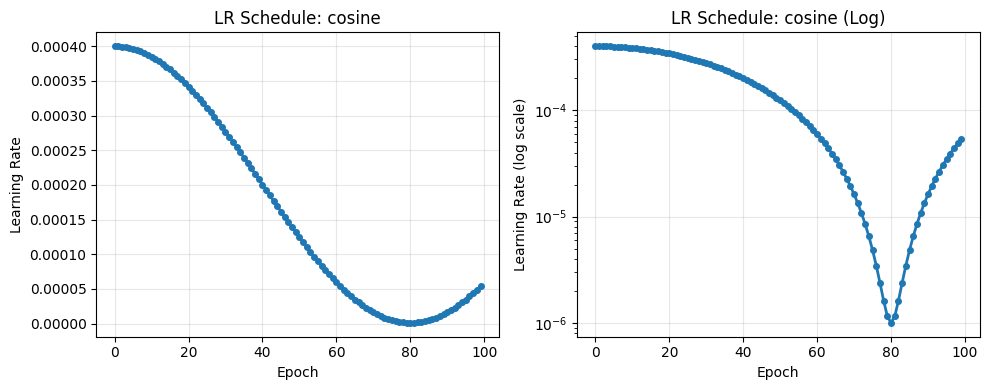

📈 LR Schedule Preview:
   Epoch  1: 4.00e-04
   Epoch  2: 4.00e-04
   Epoch  3: 3.99e-04
   Epoch  4: 3.99e-04
   Epoch  5: 3.98e-04
   Epoch  6: 3.96e-04
   Epoch  7: 3.94e-04
   Epoch  8: 3.93e-04
   Epoch  9: 3.90e-04
   Epoch 10: 3.88e-04
   ...     : ...
   Epoch 100: 5.40e-05


In [14]:
# Learning Rate Scheduler 설정
def create_lr_scheduler(optimizer, config):
    """Configuration에 따라 적절한 LR scheduler를 생성합니다."""
    
    if config.lr_scheduler is None:
        print("🚫 Learning rate scheduler: None (constant LR)")
        return None
    
    elif config.lr_scheduler == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config.cosine_T_max,
            eta_min=config.cosine_eta_min
        )
        print(f"📊 Learning rate scheduler: CosineAnnealingLR")
        print(f"   T_max: {config.cosine_T_max}, eta_min: {config.cosine_eta_min}")
        return scheduler
    
    elif config.lr_scheduler == 'cosine_warm_restarts':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=config.wr_T_0,
            T_mult=config.wr_T_mult,
            eta_min=config.wr_eta_min
        )
        print(f"🔄 Learning rate scheduler: CosineAnnealingWarmRestarts")
        print(f"   T_0: {config.wr_T_0}, T_mult: {config.wr_T_mult}, eta_min: {config.wr_eta_min}")
        return scheduler
    
    elif config.lr_scheduler == 'reduce_on_plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',  # validation loss를 minimize
            factor=config.rop_factor,
            patience=config.rop_patience,
            min_lr=config.rop_min_lr,
        )
        print(f"📉 Learning rate scheduler: ReduceLROnPlateau")
        print(f"   factor: {config.rop_factor}, patience: {config.rop_patience}, min_lr: {config.rop_min_lr}")
        return scheduler
    
    else:
        print(f"❌ Unknown scheduler: {config.lr_scheduler}, using None")
        return None

# Scheduler 생성
lr_scheduler = create_lr_scheduler(optimizer, scfg)

print(f"\n🎯 Current configuration:")
print(f"   Initial LR: {scfg.lr}")
print(f"   Scheduler: {scfg.lr_scheduler}")
print(f"   Epochs: {scfg.epochs}")

# 스케줄러별 LR 변화 시뮬레이션 (시각화용)
def simulate_lr_schedule(config, num_epochs=20):
    """LR 스케줄 변화를 시뮬레이션합니다."""
    import copy
    
    # 임시 optimizer 생성
    temp_param = torch.nn.Parameter(torch.randn(1))
    temp_opt = torch.optim.AdamW([temp_param], lr=config.lr)
    temp_scheduler = create_lr_scheduler(temp_opt, config)
    
    lrs = []
    val_losses = [1.0, 0.9, 0.85, 0.8, 0.85, 0.82, 0.81, 0.80, 0.82, 0.79,
                  0.78, 0.77, 0.78, 0.76, 0.75, 0.76, 0.74, 0.73, 0.74, 0.72]  # 가상의 validation loss
    
    for epoch in range(num_epochs):
        lrs.append(temp_opt.param_groups[0]['lr'])
        
        if temp_scheduler is not None:
            if config.lr_scheduler == 'reduce_on_plateau':
                # ReduceLROnPlateau의 경우 validation loss 필요
                val_loss = val_losses[epoch] if epoch < len(val_losses) else val_losses[-1]
                temp_scheduler.step(val_loss)
            else:
                # 다른 스케줄러는 epoch만 필요
                temp_scheduler.step()
    
    return lrs

# LR 스케줄 시각화
if scfg.lr_scheduler is not None:
    lrs = simulate_lr_schedule(scfg, scfg.epochs)
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(lrs, 'o-', linewidth=2, markersize=4)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title(f'LR Schedule: {scfg.lr_scheduler}')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.semilogy(lrs, 'o-', linewidth=2, markersize=4)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate (log scale)')
    plt.title(f'LR Schedule: {scfg.lr_scheduler} (Log)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"📈 LR Schedule Preview:")
    for i, lr in enumerate(lrs[:10]):  # 처음 10 epoch만 표시
        print(f"   Epoch {i+1:2d}: {lr:.2e}")
    if len(lrs) > 10:
        print(f"   ...     : ...")
        print(f"   Epoch {len(lrs):2d}: {lrs[-1]:.2e}")
else:
    print("📊 No scheduler selected - constant learning rate will be used.")

# wandb set-up

In [15]:
# === Weights & Biases init ===

# Type normalization helpers
def _to_list(v):
    """Convert to list if not already: str -> [str], iterable -> list, None -> None"""
    if v is None:
        return None
    if isinstance(v, str):
        return [v]
    if isinstance(v, list):
        return v
    try:
        return list(v)
    except (TypeError, ValueError):
        return None

def _validate_choice(value, valid_choices, default=None):
    """Return value if in valid_choices, else default"""
    return value if value in valid_choices else default

# Gather config dict
wandb_config = {
    "epochs": getattr(scfg, "epochs", None),
    "batch_size": getattr(scfg, "batch_size", None),
    "lr": getattr(scfg, "lr", None),
    "optimizer": getattr(scfg, "optimizer", "adam"),
    "scheduler": getattr(scfg, "scheduler", None),
    "amp": getattr(scfg, "amp", False),
    "cont_w0": getattr(loss_fn, "cont_w0", None),
    "cont_w_target": getattr(loss_fn, "cont_w_target", None),
    "mom_w0": getattr(loss_fn, "mom_w0", None),
    "mom_w_target": getattr(loss_fn, "mom_w_target", None),
    "ramp_steps": getattr(loss_fn, "curr_steps", None),
    "ramp_start_step": getattr(loss_fn, "ramp_start_step", 0),
}

# Prepare wandb.init arguments
wandb_run = wandb.init(
    project=getattr(scfg, "wandb_project", "airfrans-gnn"),
    name=getattr(scfg, "wandb_run_name", None),
    tags=_to_list(getattr(scfg, "wandb_tags", None)),
    mode=_validate_choice(getattr(scfg, "wandb_mode", "online"), 
                          ("online", "offline", "disabled", "shared"), "online"),
    settings=wandb.Settings(start_method="thread"),
    config=wandb_config,
    config_include_keys=_to_list(getattr(scfg, "wandb_config_include_keys", None)),
    config_exclude_keys=_to_list(getattr(scfg, "wandb_config_exclude_keys", None)),
    allow_val_change=getattr(scfg, "wandb_allow_val_change", None),
    reinit=_validate_choice(getattr(scfg, "wandb_reinit", None),
                            (True, False, "default", "return_previous", "finish_previous", "create_new", None)),
    resume=_validate_choice(getattr(scfg, "wandb_resume", None),
                            (True, False, "allow", "never", "must", "auto", None)),
    force=getattr(scfg, "wandb_force", None),
    save_code=getattr(scfg, "wandb_save_code", None),
    tensorboard=getattr(scfg, "wandb_tensorboard", None),
    sync_tensorboard=getattr(scfg, "wandb_sync_tensorboard", None),
    monitor_gym=getattr(scfg, "wandb_monitor_gym", None),
)


wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/chun/.netrc.
wandb: Currently logged in as: junyoungkim512 (junyoungkim512-hyundai-motor) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# 10. Execute training loop

In [16]:
# Enhanced Training Loop with Optimized W&B Artifact Management
def train_with_scheduler(model, optim, scheduler, train_loader, val_loader, 
                        scfg, device, scaler=None, physics_loss_fn=None):
    scaler = GradScaler(enabled=(scfg.amp and torch.cuda.is_available()))
    global_step = 0
    best_val = float('inf')
    
    # Artifact 관리 설정
    USE_WANDB_ARTIFACTS = getattr(scfg, "use_wandb_artifacts", False)  # 기본값 False
    ARTIFACT_SAVE_BEST_ONLY = getattr(scfg, "artifact_save_best_only", True)  # best만 저장
    ARTIFACT_SAVE_INTERVAL = getattr(scfg, "artifact_save_interval", 20)  # 20 epochs마다
    
    EPOCHS = getattr(scfg, "epochs", 50)
    ckpt_dir = getattr(scfg, "ckpt_dir", "checkpoints")
    ckpt_interval = max(1, getattr(scfg, "ckpt_interval", 5))
    
    # Artifact 히스토리 추적
    artifact_history = {
        'best_uploaded': False,
        'last_periodic_epoch': -1,
        'total_artifacts': 0
    }

    for epoch in range(EPOCHS):
        train_total, train_logs, global_step = train_epoch(
            train_loader, model, optim, device, scaler,
            desc=f"train[{epoch}]", loss_fn=physics_loss_fn,
            global_step_start=global_step,
            scheduler=scheduler,
            scheduler_step_mode=("step" if getattr(scfg, "scheduler_step_per_batch", False) else "epoch"),
            log_every_n_steps=getattr(scfg, "log_every_n_steps", 25)
        )

        val_total, val_logs = run_epoch(val_loader, model, device, loss_fn=physics_loss_fn)

        # === wandb epoch-level logging (항상 수행) ===
        log_epoch = {
            "epoch": epoch,
            "train/total_epoch": train_logs['total_loss'],
            "train/mse_epoch": train_logs['mse_loss'],
            "train/continuity_epoch": train_logs.get('continuity_loss', float('nan')),
            "train/momentum_epoch": train_logs.get('momentum_loss', float('nan')),
            "train/bc_epoch": train_logs.get('bc_loss', float('nan')),
            "val/total_epoch": val_logs['total_loss'],
            "val/mse_epoch": val_logs['mse_loss'],
            "val/continuity_epoch": val_logs.get('continuity_loss', float('nan')),
            "val/momentum_epoch": val_logs.get('momentum_loss', float('nan')),
            "val/bc_epoch": val_logs.get('bc_loss', float('nan')),
        }
        for cn in _CH_NAMES:
            log_epoch[f"train/mse_{cn}_epoch"] = train_logs.get(f'mse_{cn}', float('nan'))
            log_epoch[f"val/mse_{cn}_epoch"] = val_logs.get(f'mse_{cn}', float('nan'))
        if 'cont_weight_used' in train_logs: 
            log_epoch["weight/cont_used_epoch"] = train_logs['cont_weight_used']
        if 'mom_weight_used' in train_logs: 
            log_epoch["weight/mom_used_epoch"] = train_logs['mom_weight_used']
        lr_now = get_lr(optim)
        if lr_now is not None:
            log_epoch["lr_epoch"] = lr_now
        wandb.log(log_epoch, step=global_step, commit=True)

        # === Learning Rate Scheduler Step ===
        if scheduler is not None and not getattr(scfg, "scheduler_step_per_batch", False):
            from torch.optim.lr_scheduler import ReduceLROnPlateau
            if isinstance(scheduler, ReduceLROnPlateau):
                scheduler.step(val_total)
            else:
                scheduler.step()

        # === Checkpoint 저장 (로컬 파일시스템) ===
        os.makedirs(ckpt_dir, exist_ok=True)
        
        # Best model 저장
        is_best = val_total < best_val
        if is_best:
            best_val = val_total
            best_path = os.path.join(ckpt_dir, "best.pt")
            torch.save({
                "model": model.state_dict(),
                "optimizer": optim.state_dict(),
                "scheduler": (scheduler.state_dict() if scheduler is not None else None),
                "scaler": (scaler.state_dict() if scaler is not None else None),
                "epoch": epoch,
                "global_step": global_step,
                "best_val": best_val,
                "train_logs": train_logs,
                "val_logs": val_logs
            }, best_path)
            
            # W&B Artifact 업로드 (조건부)
            if USE_WANDB_ARTIFACTS:
                try:
                    # 이전 best artifact가 있으면 삭제 (선택적)
                    if artifact_history['best_uploaded']:
                        # W&B는 자동으로 버전 관리하므로 별도 삭제 불필요
                        pass
                    
                    # 새로운 best artifact 업로드
                    art = wandb.Artifact(
                        name=f"model-best",  # 고정된 이름 사용
                        type="model",
                        description=f"Best model at epoch {epoch} with val_loss={val_total:.4f}",
                        metadata={
                            "epoch": epoch,
                            "val_loss": val_total,
                            "train_loss": train_total,
                            "best_val": best_val
                        }
                    )
                    art.add_file(best_path)
                    wandb.run.log_artifact(art)
                    artifact_history['best_uploaded'] = True
                    artifact_history['total_artifacts'] += 1
                    print(f"  📤 W&B Artifact uploaded: best model (epoch {epoch})")
                except Exception as e:
                    print(f"  ⚠️ Failed to upload W&B artifact: {e}")

        # Periodic checkpoint 저장
        if (epoch + 1) % ckpt_interval == 0:
            ep_path = os.path.join(ckpt_dir, f"epoch_{epoch+1}.pt")
            torch.save({
                "model": model.state_dict(),
                "optimizer": optim.state_dict(),
                "scheduler": (scheduler.state_dict() if scheduler is not None else None),
                "scaler": (scaler.state_dict() if scaler is not None else None),
                "epoch": epoch,
                "global_step": global_step,
                "best_val": best_val
            }, ep_path)
            
            # Periodic artifact 업로드 (매우 제한적으로)
            if USE_WANDB_ARTIFACTS and not ARTIFACT_SAVE_BEST_ONLY:
                if (epoch + 1) % ARTIFACT_SAVE_INTERVAL == 0:
                    try:
                        art = wandb.Artifact(
                            name=f"model-checkpoint",
                            type="model",
                            description=f"Checkpoint at epoch {epoch+1}",
                            metadata={
                                "epoch": epoch + 1,
                                "val_loss": val_total,
                                "train_loss": train_total
                            }
                        )
                        art.add_file(ep_path)
                        wandb.run.log_artifact(art, aliases=[f"epoch-{epoch+1}"])
                        artifact_history['last_periodic_epoch'] = epoch + 1
                        artifact_history['total_artifacts'] += 1
                        print(f"  📤 W&B Artifact uploaded: checkpoint (epoch {epoch+1})")
                    except Exception as e:
                        print(f"  ⚠️ Failed to upload periodic artifact: {e}")

        # Print epoch summary
        print(f"Epoch {epoch:3d} | Train: total={train_total:.4f} mse={train_logs['mse_loss']:.4f} "
              f"cont={train_logs.get('continuity_loss', 0):.2e} mom={train_logs.get('momentum_loss', 0):.2e} "
              f"bc={train_logs.get('bc_loss', 0):.2e} | "
              f"Val: total={val_total:.4f} bc={val_logs.get('bc_loss', 0):.2e}"
              f" {'[BEST]' if is_best else ''}")

    # === Training 완료 후 최종 artifact ===
    if USE_WANDB_ARTIFACTS:
        # 최종 모델 저장
        final_path = os.path.join(ckpt_dir, "final.pt")
        torch.save({
            "model": model.state_dict(),
            "optimizer": optim.state_dict(),
            "scheduler": (scheduler.state_dict() if scheduler is not None else None),
            "scaler": (scaler.state_dict() if scaler is not None else None),
            "epoch": EPOCHS - 1,
            "global_step": global_step,
            "best_val": best_val
        }, final_path)
        
        try:
            art = wandb.Artifact(
                name=f"model-final",
                type="model",
                description=f"Final model after {EPOCHS} epochs",
                metadata={
                    "total_epochs": EPOCHS,
                    "best_val": best_val,
                    "total_artifacts": artifact_history['total_artifacts']
                }
            )
            art.add_file(final_path)
            art.add_file(os.path.join(ckpt_dir, "best.pt"), name="best.pt")  # best도 포함
            wandb.run.log_artifact(art, aliases=["latest", "final"])
            print(f"\n📤 Final W&B Artifact uploaded with {artifact_history['total_artifacts']+1} total artifacts")
        except Exception as e:
            print(f"⚠️ Failed to upload final artifact: {e}")

    # 종료
    wandb.finish()
    
    return {
        'lr_history': [],
        'train_total_loss': [],
        'train_continuity_loss': [],
        'train_bc_loss': [],
        'val_total_loss': [],
        'val_continuity_loss': [],
        'val_bc_loss': [],
        'artifacts_uploaded': artifact_history['total_artifacts']
    }

# 훈련 실행 함수 (Physics Loss 지원)
def run_training_experiment(config_updates=None, physics_config_updates=None):
    """
    설정을 업데이트하고 physics loss와 함께 훈련을 실행합니다.
    
    Args:
        config_updates: 모델 설정 변경 딕셔너리 (예: {'lr_scheduler': 'cosine'})
        physics_config_updates: Physics loss 설정 변경 딕셔너리
    """
    
    # 설정 업데이트
    if config_updates:
        for key, value in config_updates.items():
            setattr(scfg, key, value)
        print(f"🔧 Model configuration updated: {config_updates}")
    


    # 새로운 optimizer와 scheduler 생성
    optimizer = torch.optim.AdamW(model.parameters(), 
                                 lr=scfg.lr, 
                                 weight_decay=scfg.weight_decay, 
                                 betas=scfg.betas, 
                                 eps=scfg.eps)
    
    scheduler = create_lr_scheduler(optimizer, scfg)
    
    # GradScaler for AMP
    scaler = torch.cuda.amp.GradScaler() if scfg.amp and torch.cuda.is_available() else None
    
    # 훈련 실행
    history = train_with_scheduler(
        model, optimizer, scheduler, train_loader, val_loader, 
        scfg, device, scaler, physics_loss_fn=loss_fn
    )
    
    return history


# 스케줄러 및 Physics Loss 테스트
print(f"Current scheduler: {scfg.lr_scheduler}")

if lr_scheduler is None:
    print("⚠️  No scheduler active - training with constant LR")
else:
    print(f"✅ Scheduler ready: {type(lr_scheduler).__name__}")

print(f"\n🧪 Running test training with physics loss...")

# 짧은 훈련으로 테스트 (physics loss 포함)
test_history = run_training_experiment()

print(f"\n📊 Test Results with Physics Loss:")
if test_history['lr_history']:
    print(f"   LR progression: {' -> '.join([f'{lr:.2e}' for lr in test_history['lr_history']])}")
    print(f"   Train losses (total): {' -> '.join([f'{loss:.4f}' for loss in test_history['train_total_loss']])}")
    print(f"   Train losses (continuity): {' -> '.join([f'{loss:.2e}' for loss in test_history['train_continuity_loss']])}")
    print(f"   Val losses (total): {' -> '.join([f'{loss:.4f}' for loss in test_history['val_total_loss']])}")
    print(f"   Val losses (continuity): {' -> '.join([f'{loss:.2e}' for loss in test_history['val_continuity_loss']])}")
else:
    print("   Training was interrupted before any results could be recorded.")


/tmp/ipykernel_124523/3465280348.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(scfg.amp and torch.cuda.is_available()))


Current scheduler: cosine
✅ Scheduler ready: CosineAnnealingLR

🧪 Running test training with physics loss...
📊 Learning rate scheduler: CosineAnnealingLR
   T_max: 80, eta_min: 1e-06


val:   0%|          | 0/200 [00:00<?, ?it/s]                                                                                                   /tmp/ipykernel_124523/2167044274.py:85: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with (autocast(enabled=(scfg.amp and torch.cuda.is_available()))


Epoch   0 | Train: total=110.9573 mse=1.0151 cont=2.92e-04 mom=2.20e+03 bc=1.62e+00 | Val: total=1.0034 bc=3.49e-02 [BEST]


Epoch   1 | Train: total=1.0254 mse=1.0082 cont=5.45e-05 mom=3.42e-01 bc=1.28e-02 | Val: total=0.9912 bc=1.60e-02 [BEST]


...

Epoch  31 | Train: total=0.8098 mse=0.7527 cont=3.65e-03 mom=6.48e-01 bc=4.70e-01 | Val: total=0.8015 bc=5.74e-01 [BEST]


train[32]:  38%|███▊      | 304/800 [00:20<00:33, 14.65it/s, total=1.8526e-01, lr=2.62e-04, cont=4.9093e-03, momentum=1.3726e-01, bc=4.8505e-02]

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for post_run_cell), with arguments args (<ExecutionResult object at 7e271a3a0d10, execution_count=16 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7e253609cfd0, raw_cell="# Enhanced Training Loop with Optimized W&B Artifa.." transformed_cell="# Enhanced Training Loop with Optimized W&B Artifa.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X40sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [18]:
from src.utils import get_surface_mask, ensure_edge_features

# 14b) MSE per target (all, surface, volume) — computed in NORMALIZED space
@torch.no_grad()
def _surface_volume_masks_from_orig(d: Data):
    # Surface: non-zero normal vectors; Volume: zero normal vectors (use original, unnormalized normals)
    x = d.x
    if x is not None and x.size(1) >= 5:
        nxy = x[:, 3:5]
        surf = (nxy.abs().sum(dim=1) > 0)
    else:
        # Fallback to earlier heuristic
        surf = get_surface_mask(d)
    vol = ~surf
    return surf, vol

@torch.no_grad()
def _predict_one_local(d: Data):
    # Ensure pos3 and edges; normalize x; predict; keep EVERYTHING in normalized space for eval
    dm = Data(**{k: v for k, v in d})
    if dm.x.size(1) == 5 or not getattr(dm, 'pos2_appended', False):
        dm = with_pos2(dm)
    # edges must already exist; do not build inline
    assert hasattr(dm,'edge_index') and dm.edge_index is not None, 'edge_index missing'
    dm = ensure_edge_features(dm, want_dim=5)
    dm.x_orig = dm.x

    # Build a CPU copy with normalized x/y for evaluation and metrics
    dm_norm = Data(**{k: v for k, v in dm})
    dm_norm.x = dm.x  # assume already normalized
    dm_norm.y = dm.y  # assume already normalized
    dm_norm.x_orig = dm.x
    dm_norm.x_norm_params = {'mean': x_scaler.mean.clone(), 'scale': x_scaler.std.clone()}
    dm_norm.y_norm_params = {'mean': y_scaler.mean.clone(), 'scale': y_scaler.std.clone()}

    # Forward on device, return prediction in normalized space on CPU
    dm_run = dm_norm.to(device)
    with torch.amp.autocast(device_type='cuda', enabled=(scfg.amp and torch.cuda.is_available())) if torch.cuda.is_available() else contextlib.nullcontext():
        y_pred_norm = model(dm_run).detach().cpu()
    return dm_norm, y_pred_norm

@torch.no_grad()
def mse_per_channel(y_pred: torch.Tensor, y_true: torch.Tensor, mask: torch.Tensor | None = None):
    # Ensure both tensors (and mask) are on the same device as y_pred
    dev = y_pred.device
    y_t = y_true.to(dev)
    if mask is not None:
        m = mask.to(dev)
        y_p = y_pred[m]
        y_t = y_t[m]
    else:
        y_p = y_pred
    err = (y_p - y_t) ** 2
    if err.numel() == 0:
        return [float('nan')] * y_true.size(1)
    return [float(err[:, i].mean().item()) for i in range(y_true.size(1))]

# Pick a sample (val if available else train) and report MSE splits (normalized space)
if isinstance(val_edges, list) and len(val_edges) > 0:
    d_eval = val_edges[0]
else:
    d_eval = train_edges[0] if len(train_edges) > 0 else None

if d_eval is not None:
    # Use original graph (unnormalized x) only for surface/volume masks
    d_orig = d_eval
    dm_eval_norm, y_pred_eval_norm = _predict_one_local(d_orig)
    surf_mask, vol_mask = _surface_volume_masks_from_orig(d_orig)

    names = ['u', 'v', 'p_over_rho', 'nu_t']
    mse_all = mse_per_channel(y_pred_eval_norm, dm_eval_norm.y, None)
    mse_surf = mse_per_channel(y_pred_eval_norm, dm_eval_norm.y, surf_mask)
    mse_vol  = mse_per_channel(y_pred_eval_norm, dm_eval_norm.y, vol_mask)

    print('[MSE | ALL   | normalized]', {n: f'{v:.4e}' for n, v in zip(names, mse_all)})
    print('[MSE | SURF  | normalized]', {n: f'{v:.4e}' for n, v in zip(names, mse_surf)})
    print('[MSE | VOLUME| normalized]', {n: f'{v:.4e}' for n, v in zip(names, mse_vol)})
else:
    print('No sample available for MSE computation')

# Compute MSE statistics over entire validation set
if val_loader is not None and len(val_loader) > 0:
    all_mse_all = []
    all_mse_surf = []
    all_mse_vol = []
    
    for batch in val_loader:
        # For each graph in batch
        for i in range(batch.num_graphs):
            # Extract single graph
            d = batch.get_example(i)
            dm_eval_norm, y_pred_eval_norm = _predict_one_local(d)
            surf_mask, vol_mask = _surface_volume_masks_from_orig(d)
            
            mse_all = mse_per_channel(y_pred_eval_norm, dm_eval_norm.y, None)
            mse_surf = mse_per_channel(y_pred_eval_norm, dm_eval_norm.y, surf_mask)
            mse_vol = mse_per_channel(y_pred_eval_norm, dm_eval_norm.y, vol_mask)
            
            all_mse_all.append(mse_all)
            all_mse_surf.append(mse_surf)
            all_mse_vol.append(mse_vol)
    
    if all_mse_all:
        import numpy as np
        mse_all_array = np.array(all_mse_all)
        mse_surf_array = np.array(all_mse_surf)
        mse_vol_array = np.array(all_mse_vol)
        
        names = ['u', 'v', 'p_over_rho', 'nu_t']
        print('\n[Validation Set Statistics | ALL | normalized]')
        for i, n in enumerate(names):
            mean_val = mse_all_array[:, i].mean()
            std_val = mse_all_array[:, i].std()
            print(f'{n}: mean={mean_val:.4e}, std={std_val:.4e}')
        
        print('\n[Validation Set Statistics | SURF | normalized]')
        for i, n in enumerate(names):
            mean_val = mse_surf_array[:, i].mean()
            std_val = mse_surf_array[:, i].std()
            print(f'{n}: mean={mean_val:.4e}, std={std_val:.4e}')
        
        print('\n[Validation Set Statistics | VOLUME | normalized]')
        for i, n in enumerate(names):
            mean_val = mse_vol_array[:, i].mean()
            std_val = mse_vol_array[:, i].std()
            print(f'{n}: mean={mean_val:.4e}, std={std_val:.4e}')
else:
    print('No validation loader available for statistics computation')

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7e252c10ffd0, raw_cell="from src.utils import get_surface_mask, ensure_edg.." transformed_cell="from src.utils import get_surface_mask, ensure_edg.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X41sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

[MSE | ALL   | normalized] {'u': '9.6458e+02', 'v': '3.6031e+00', 'p_over_rho': '8.2770e+03', 'nu_t': '2.3314e+00'}
[MSE | SURF  | normalized] {'u': '2.3785e-02', 'v': '1.4223e-01', 'p_over_rho': '9.2781e+04', 'nu_t': '6.6287e-03'}
[MSE | VOLUME| normalized] {'u': '1.0217e+03', 'v': '3.8082e+00', 'p_over_rho': '3.2699e+03', 'nu_t': '2.4692e+00'}


socket.send() raised exception.
socket.send() raised exception.



[Validation Set Statistics | ALL | normalized]
u: mean=1.0295e+00, std=7.1776e-01
v: mean=1.2427e+00, std=1.6409e+00
p_over_rho: mean=4.9096e-01, std=1.5524e+00
nu_t: mean=1.5038e-01, std=3.8808e-01

[Validation Set Statistics | SURF | normalized]
u: mean=1.0295e+00, std=7.1776e-01
v: mean=1.2427e+00, std=1.6409e+00
p_over_rho: mean=4.9096e-01, std=1.5524e+00
nu_t: mean=1.5038e-01, std=3.8808e-01

[Validation Set Statistics | VOLUME | normalized]
u: mean=nan, std=nan
v: mean=nan, std=nan
p_over_rho: mean=nan, std=nan
nu_t: mean=nan, std=nan
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for post_run_cell), with arguments args (<ExecutionResult object at 7e2524b24d10, execution_count=18 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7e252c10ffd0, raw_cell="from src.utils import get_surface_mask, ensure_edg.." transformed_cell="from src.utils import get_surface_mask, ensure_edg.." st

BrokenPipeError: [Errno 32] Broken pipe

# Result Visualization

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7e2472658fd0, raw_cell="# 15) Visualization: GT vs Prediction (tricontour .." transformed_cell="# 15) Visualization: GT vs Prediction (tricontour .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X43sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

[Saved] figures/pred_vs_gt_channel2_20260204_044311.png


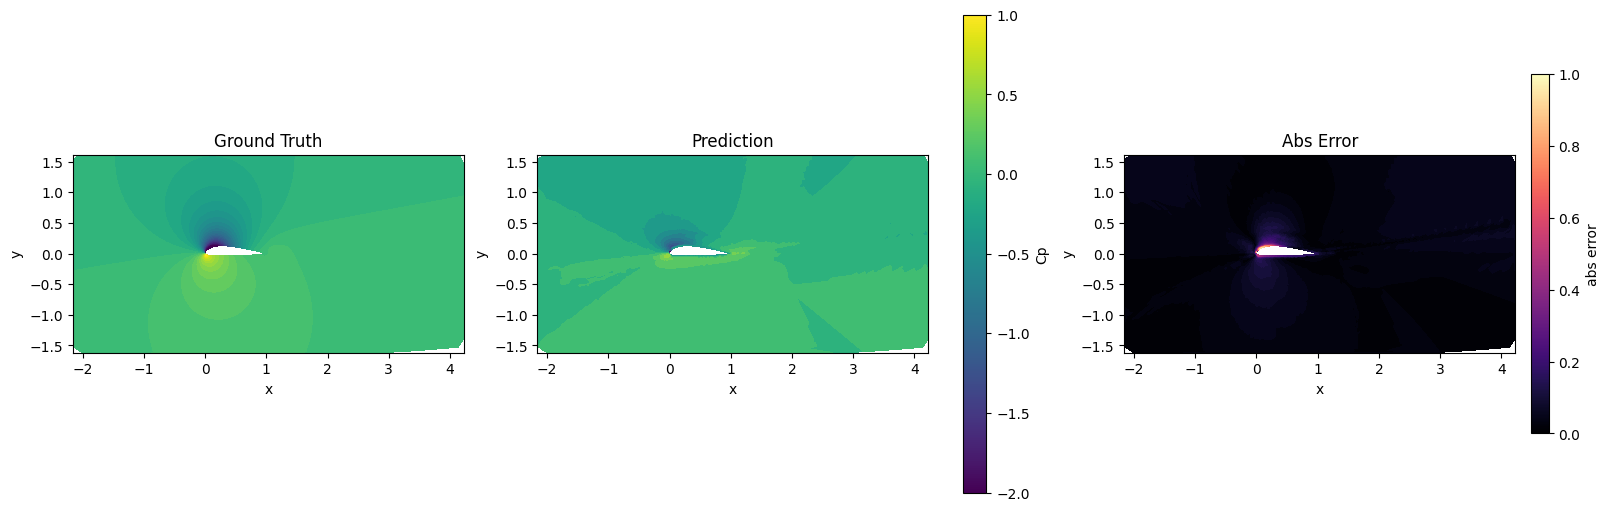

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for post_run_cell), with arguments args (<ExecutionResult object at 7e247265abd0, execution_count=19 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7e2472658fd0, raw_cell="# 15) Visualization: GT vs Prediction (tricontour .." transformed_cell="# 15) Visualization: GT vs Prediction (tricontour .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X43sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [19]:
# 15) Visualization: GT vs Prediction (tricontour with optional mask)
from matplotlib.tri import Triangulation
from matplotlib.path import Path
from src.utils import _poly_from_surface
import os
from datetime import datetime

@torch.no_grad()
def _predict_one_for_viz(d: Data):
    # Ensure pos3 + edges, normalize x/y, forward, return normalized dm and y_pred_norm
    dm = Data(**{k: v for k, v in d})
    if dm.x.size(1) == 5 or not getattr(dm, 'pos2_appended', False):
        dm = with_pos2(dm)
    assert hasattr(dm,'edge_index') and dm.edge_index is not None, 'edge_index missing'
    dm = ensure_edge_features(dm, want_dim=5)
    dm_norm = Data(**{k: v for k, v in dm})
    dm_norm.x = x_scaler.transform(dm.x)
    dm_norm.y = y_scaler.transform(dm.y)
    dm_run = dm_norm.to(device)
    
    # Temporarily disable AMP for visualization to avoid dtype issues
    model.eval()
    # Force float32 for visualization to avoid AMP dtype conflicts
    if hasattr(dm_run, 'x'):
        dm_run.x = dm_run.x.float()
    if hasattr(dm_run, 'edge_attr'):
        dm_run.edge_attr = dm_run.edge_attr.float()
        
    y_pred_norm = model(dm_run).detach().cpu()
    return dm_norm, y_pred_norm

@torch.no_grad()
def plot_pred_vs_gt(dm: Data, y_pred: torch.Tensor, channel: int = 2, show_mesh: bool = True, mask_airfoil: bool = True,
                    titles: tuple[str,str,str] = ('Ground Truth','Prediction','Abs Error'), cmap: str = 'viridis',
                    denormalize: bool = True, save_dir: str = "figures", save: bool = True):
    # Optionally denormalize both GT and prediction for visualization
    if denormalize and hasattr(dm, 'y'):
        dm_y_cpu = dm.y.detach().cpu()
        y_pred_cpu = y_pred.detach().cpu()
        gt = y_scaler.inverse(dm_y_cpu)
        pr = y_scaler.inverse(y_pred_cpu)
    else:
        gt = dm.y.detach().cpu()
        pr = y_pred.detach().cpu()

    # Prepare coordinates and values
    xy = (dm.pos if hasattr(dm,'pos') and dm.pos is not None else dm.x)[:, :2].detach().cpu().float().numpy()
    tri = Triangulation(xy[:,0], xy[:,1])

    # Denormalize x to physical for q and for robust airfoil polygon detection
    dm_x_cpu = dm.x.detach().cpu()
    x_phys = x_scaler.inverse(dm_x_cpu)  
    vx = float(x_phys[0, 0]); vy = float(x_phys[0, 1])
    v = math.sqrt(vx*vx + vy*vy)
    q = 0.5 * v * v

    gt_c = gt[:, channel].detach().cpu().float().numpy() / q
    pr_c = pr[:, channel].detach().cpu().float().numpy() / q
    err = np.abs(pr_c - gt_c)
    vmin = -2.0; vmax = 1.0

    # Optional mask of airfoil interior
    if mask_airfoil:
        try:
            x_np = x_phys.detach().cpu().numpy() if isinstance(x_phys, torch.Tensor) else np.asarray(x_phys)
            pos_np = (dm.pos if hasattr(dm,'pos') and dm.pos is not None else dm.x)[:, :2].detach().cpu().numpy()
            surf_mask = None
            try:
                wall = x_np[:, 2] if x_np.shape[1] >= 3 else None
                nxy = x_np[:, 3:5] if x_np.shape[1] >= 5 else None
                if nxy is not None:
                    surf_mask = (np.abs(nxy).sum(axis=1) > 1e-8)
                    if wall is not None:
                        surf_mask = np.logical_or(surf_mask, (wall < 1e-6))
                elif wall is not None:
                    surf_mask = (wall < 1e-6)
            except Exception:
                surf_mask = None

            poly = None
            if surf_mask is not None and np.any(surf_mask):
                pts = pos_np[surf_mask]
                if pts.shape[0] >= 3:
                    c = pts.mean(axis=0)
                    ang = np.arctan2(pts[:,1]-c[1], pts[:,0]-c[0])
                    order = np.argsort(ang)
                    poly = Path(pts[order], closed=True)

            if poly is not None:
                tris = tri.triangles
                centers = np.mean(np.stack([tri.x[tris], tri.y[tris]], axis=-1), axis=1)
                inside = poly.contains_points(centers, radius=-1e-6)
                if inside is not None and inside.any():
                    tri.set_mask(inside.astype(bool))
        except Exception:
            pass

    fig, ax = plt.subplots(1, 3, figsize=(16,5), constrained_layout=True)
    a1,a2,a3 = ax
    c1 = a1.tricontourf(tri, gt_c, levels=50, vmin=vmin, vmax=vmax, cmap=cmap)
    c2 = a2.tricontourf(tri, pr_c, levels=50, vmin=vmin, vmax=vmax, cmap=cmap)
    c3 = a3.tricontourf(tri, err, levels=50, cmap='magma')
    if show_mesh:
        for a in (a1,a2,a3):
            a.triplot(tri, color='k', lw=0.25, alpha=0.35)
    for a, t in zip((a1,a2,a3), titles):
        a.set_aspect('equal','box'); a.set_title(t); a.set_xlabel('x'); a.set_ylabel('y')
    m1 = plt.cm.ScalarMappable(cmap=cmap); m1.set_clim(vmin,vmax)
    fig.colorbar(m1, ax=[a1,a2], fraction=0.046, pad=0.04, label=f'Cp')
    fig.colorbar(plt.cm.ScalarMappable(cmap='magma'), ax=a3, fraction=0.046, pad=0.04, label='abs error')

    # === Save figure with timestamp ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = os.path.join(save_dir, f"pred_vs_gt_channel{channel}_{timestamp}.png")
        plt.savefig(filename, dpi=200)
        print(f"[Saved] {filename}")

    plt.show()


# Example: visualize one sample (val if available, else train) — denormalized to capture actual flow physics
if isinstance(val_edges, list) or len(val_edges)==0:
    d_vis = train_edges[0] if len(train_edges)>0 else None
else:
    d_vis = val_edges[0] if len(val_edges)>0 else (train_edges[0] if len(train_edges)>0 else None)

if d_vis is not None:
    dm_vis_n, y_pred_vis_n = _predict_one_for_viz(d_vis)
    # Plot for pressure by default (channel 2). Change channel as needed (0=u, 1=v, 2=p_over_rho, 3=nu_t).
    plot_pred_vs_gt(dm_vis_n, y_pred_vis_n, channel=2, show_mesh=False, denormalize=True)
else:
    print('No sample available for visualization')


In [20]:
# New cell for force coefficient calculation and comparison

from src.force_coefficients_calculation import compute_force_coefficients

def order_surface(pos_surf: torch.Tensor):
    c = pos_surf.mean(dim=0)
    rel = pos_surf - c
    angles = torch.atan2(rel[:,1], rel[:,0])
    return torch.argsort(angles)

def panel_lengths(pos_ordered: torch.Tensor):
    rolled = torch.roll(pos_ordered, -1, 0)
    seg = rolled - pos_ordered
    ds = seg.norm(dim=1)
    return ds, seg

def compute_force_coefficients(data: Data, eps=1e-9):
    """
    Compute drag coefficient (CD) and lift coefficient (CL) from surface pressure.
    
    Args:
        data: PyG Data object with x (features), y (targets), pos (positions)
        eps: small value to avoid division by zero
    
    Returns:
        dict with 'CD' and 'CL' if successful, None otherwise
    """
    xvars = torch.tensor(data.x) if not isinstance(data.x, torch.Tensor) else data.x.cpu()
    yvars = torch.tensor(data.y) if not isinstance(data.y, torch.Tensor) else data.y.cpu()
    pos = torch.tensor(data.pos) if data.pos is not None and not isinstance(data.pos, torch.Tensor) else (data.pos.cpu() if data.pos is not None else data.pos)
    if pos is None:
        # fallback: construct pseudo-pos from first 2 normal dims (NOT ideal)
        N = xvars.size(0)
        pos = torch.zeros(N,2)
        pos[:,0] = torch.linspace(0,1,N)
        pos[:,1] = 0
    
    # Surface mask: feature columns 4-5 (normals) are not zero
    normals = xvars[:,3:5]
    surf_mask = (normals.abs().sum(dim=1) > 0)
    surf_idx = torch.nonzero(surf_mask, as_tuple=False).squeeze(-1).long()
    if surf_idx.numel() < 5:
        return None
    
    pos_surf = pos[surf_idx]
    ord_idx = order_surface(pos_surf).long()
    ordered_pos = pos_surf[ord_idx]
    ds, seg_vec = panel_lengths(ordered_pos)
    n_nodes = normals[surf_idx[ord_idx]]
    n_norm = n_nodes.norm(dim=1, keepdim=True).clamp_min(eps)
    n_hat = n_nodes / n_norm
    
    # Freestream velocity: denormalize from normalized features
    if hasattr(data, 'x_norm_params'):
        mean = data.x_norm_params['mean']
        scale = data.x_norm_params['scale']
        u_inf = xvars[0,0] * scale[0] + mean[0]
        v_inf = xvars[0,1] * scale[1] + mean[1]
    else:
        u_inf = xvars[0,0]; v_inf = xvars[0,1]
    U_inf = float(torch.sqrt(u_inf**2 + v_inf**2)) + eps
    
    temp = torch.index_select(yvars, 0, surf_idx)[:,2]
    p_over_rho = temp[ord_idx]
    Fp = (-p_over_rho.unsqueeze(1) * n_hat) * ds.unsqueeze(1)
    F = Fp.sum(dim=0)  # Total force [Fx, Fy]
    
    # Chord length
    chord = float(pos_surf[:,0].max() - pos_surf[:,0].min() + eps)
    
    # Dynamic pressure
    q_ref = 0.5 * U_inf**2
    
    # Coefficients
    CD = -F[0] / (q_ref * chord + eps)
    CL = F[1] / (q_ref * chord + eps)
    
    return {'CD': float(CD), 'CL': float(CL)}

@torch.no_grad()
def predict_and_denormalize(d: Data):
    """
    Perform prediction and return denormalized results.
    """
    dm_norm, y_pred_norm = _predict_one_local(d)
    # Denormalize prediction
    y_pred_denorm = y_scaler.inverse(y_pred_norm.cpu())
    # Ground truth is already in dm_norm.y, denormalize it too
    y_true_denorm = y_scaler.inverse(dm_norm.y.cpu())
    # Create data with denormalized y
    dm_denorm = Data(**{k: v for k, v in dm_norm})
    dm_denorm.y = y_true_denorm
    dm_denorm.x = d.x
    return dm_denorm, y_pred_denorm

@torch.no_grad()
def compare_force_coefficients(d: Data):
    """
    Compare CD and CL from predicted and ground truth pressures.
    """
    dm_denorm, y_pred_denorm = predict_and_denormalize(d)
    
    # Create data for ground truth
    d_gt = Data(**{k: v for k, v in dm_denorm})
    # d_gt.y is already ground truth denormalized
    
    # Create data for prediction
    d_pred = Data(**{k: v for k, v in dm_denorm})
    d_pred.y = y_pred_denorm
    
    # Compute coefficients
    coeffs_gt = compute_force_coefficients(d_gt)
    coeffs_pred = compute_force_coefficients(d_pred)
    
    if coeffs_gt is None or coeffs_pred is None:
        print("Could not compute force coefficients (insufficient surface nodes)")
        return None
    
    print(f"Ground Truth - CD: {coeffs_gt['CD']:.6f}, CL: {coeffs_gt['CL']:.6f}")
    print(f"Prediction   - CD: {coeffs_pred['CD']:.6f}, CL: {coeffs_pred['CL']:.6f}")
    print(f"Difference   - CD: {coeffs_pred['CD'] - coeffs_gt['CD']:.6f}, CL: {coeffs_pred['CL'] - coeffs_gt['CL']:.6f}")
    
    return coeffs_gt, coeffs_pred

# Test on a sample
for batch in val_loader:
    for i in range(batch.num_graphs):
        d = batch.get_example(i)
        results = compare_force_coefficients(d)
        break  # just one sample
    break  # just one batch

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7e24722a7510, raw_cell="# New cell for force coefficient calculation and c.." transformed_cell="# New cell for force coefficient calculation and c.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X44sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.
socket.send() raised exception.


Ground Truth - CD: -45.274635, CL: 10.403551
Prediction   - CD: -207.399582, CL: 5.588124
Difference   - CD: -162.124947, CL: -4.815427
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for post_run_cell), with arguments args (<ExecutionResult object at 7e2471565510, execution_count=20 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7e24722a7510, raw_cell="# New cell for force coefficient calculation and c.." transformed_cell="# New cell for force coefficient calculation and c.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X44sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [20]:
print(train_norm[0])

for dd in val_norm:
    results = compare_force_coefficients(dd)
    


Data(
  x=[17987, 7],
  edge_index=[2, 68640],
  edge_attr=[68640, 5],
  y=[17987, 4],
  pos=[17987, 2],
  surf=[17987],
  orig_index=0,
  edge_attr_dxdy=[68640, 3],
  edge_meta={
    global_radius=0.02,
    surface_radius=0.01,
    edge_count=68640,
    surf_edge_count=19812,
    schemas={
      edge_attr={
        desc='dist, dir_x, dir_y, cos_n, is_surface_pair',
        columns=[5],
      },
      edge_attr_dxdy={
        desc='dx, dy, dist',
        columns=[3],
      },
    },
  },
  pos2_appended=True,
  has_norm=True,
  is_wall=[17987],
  wall_normal=[17987, 2],
  is_inlet=[17987],
  is_outlet=[17987],
  is_farfield=[17987],
  inlet_u=[17987, 2]
)
Ground Truth - CD: -45.419044, CL: 10.552406
Prediction   - CD: -377.670898, CL: 12.737872
Difference   - CD: -332.251854, CL: 2.185466
Ground Truth - CD: 22.411650, CL: 86.670517
Prediction   - CD: -238.055557, CL: 6.910380
Difference   - CD: -260.467207, CL: -79.760137
Ground Truth - CD: -11.153149, CL: 52.444572
Prediction   - CD: 

Ground Truth - CD: -30.292637, CL: -14.846483
Prediction   - CD: -91.501549, CL: 3.281018
Difference   - CD: -61.208912, CL: 18.127501


Ground Truth - CD: -44.325283, CL: -10.074407
Prediction   - CD: -110.968384, CL: 3.449658
Difference   - CD: -66.643101, CL: 13.524065
Ground Truth - CD: 18.301208, CL: 70.637085
Prediction   - CD: -42.085457, CL: 1.382709
Difference   - CD: -60.386665, CL: -69.254376
Ground Truth - CD: -24.163712, CL: 37.822140
Prediction   - CD: -232.377899, CL: 7.806965
Difference   - CD: -208.214188, CL: -30.015175
Ground Truth - CD: -46.538403, CL: -4.478584
Prediction   - CD: -199.003937, CL: 7.151981
Difference   - CD: -152.465534, CL: 11.630565


socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7e2471532390, raw_cell="import matplotlib.pyplot as plt

@torch.no_grad()
.." transformed_cell="import matplotlib.pyplot as plt

@torch.no_grad()
.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X50sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

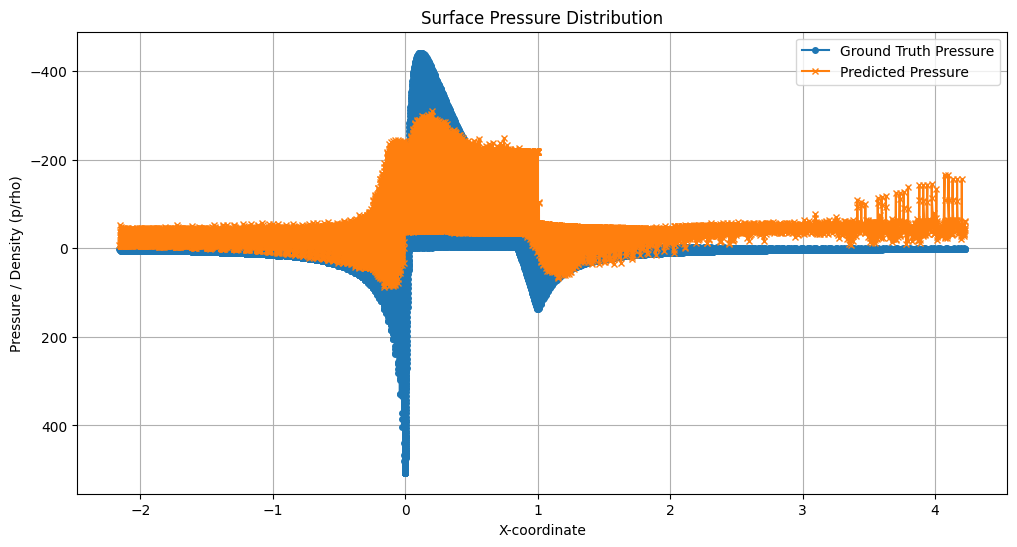

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7e27187b5010>> (for post_run_cell), with arguments args (<ExecutionResult object at 7e2471533d10, execution_count=21 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7e2471532390, raw_cell="import matplotlib.pyplot as plt

@torch.no_grad()
.." transformed_cell="import matplotlib.pyplot as plt

@torch.no_grad()
.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/home/chun/work/airfrans_gnn/01_trainer_executed.ipynb#X50sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [21]:
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_surface_pressure(d: Data):
    """
    Plots the surface pressure distribution for ground truth and prediction.
    """
    dm_denorm, y_pred_denorm = predict_and_denormalize(d)
    
    # --- Get Surface Data ---
    xvars = dm_denorm.x.cpu()
    pos = dm_denorm.pos.cpu()
    
    normals = xvars[:, 3:5]
    surf_mask = (normals.abs().sum(dim=1) > 0)
    surf_idx = torch.nonzero(surf_mask, as_tuple=False).squeeze(-1).long()
    
    if surf_idx.numel() < 5:
        print("Not enough surface nodes to plot.")
        return

    pos_surf = pos[surf_idx]
    
    # Order points by x-coordinate for plotting
    ord_idx = torch.argsort(pos_surf[:, 0])
    ordered_pos = pos_surf[ord_idx]
    
    # --- Ground Truth Pressure ---
    y_true_denorm = dm_denorm.y.cpu()
    p_true = torch.index_select(y_true_denorm, 0, surf_idx)[:, 2]
    p_true_ordered = p_true[ord_idx]

    # --- Predicted Pressure ---
    p_pred = torch.index_select(y_pred_denorm, 0, surf_idx)[:, 2]
    p_pred_ordered = p_pred[ord_idx]

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(ordered_pos[:, 0], p_true_ordered, 'o-', label='Ground Truth Pressure', markersize=4)
    ax.plot(ordered_pos[:, 0], p_pred_ordered, 'x-', label='Predicted Pressure', markersize=4)
    
    ax.set_xlabel('X-coordinate')
    ax.set_ylabel('Pressure / Density (p/rho)')
    ax.set_title('Surface Pressure Distribution')
    ax.legend()
    ax.grid(True)
    plt.gca().invert_yaxis() # In aerodynamics, it's common to plot negative pressure upwards
    plt.show()

# Plot for the same sample used in the force calculation
if 'd' in locals():
    plot_surface_pressure(d)
else:
    print("Sample 'd' not found. Please run the previous cell to select a sample.")
